# Plateau’s Problem (or minimal surface problem)

This notebook provides an implementation of the Plateau's problem, which finds a minimal surface shape that connects a set of interfaces.
More details on this example, can be found in [our paper](https://arxiv.org/abs/2402.14009), Sections 4.1 and A.2.

### Imports and setup

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm.notebook import trange
import k3d
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from external.preconditioning.model_architecture import GeneralNet
from external.preconditioning.optimizers import HandNGD 

## Point-sampler
from GINN.numerical_boundary import find_boundary_points_numerically_with_binsearch
from models.net_w_partials import NetWithPartials
from util.sample_utils import precompute_sample_grid

torch.manual_seed(0)

device = 'cuda' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

### Define the boundary rectangles

In [16]:
def get_boundary_angled_rectangles(n=1000):
    ls = lambda a,b : torch.linspace(a, b, n//8, device=device)
    const = lambda c : c*torch.ones(n//8, device=device, dtype=torch.float32)
    boundary = torch.hstack([
        torch.vstack([ls(0,1), const(0), const(0)]),
        torch.vstack([ls(0,1), const(1), const(0)]),
        torch.vstack([const(0), const(0), ls(0,1)]),
        torch.vstack([const(0), ls(0,1), const(1)]),
        torch.vstack([const(0), const(1), ls(0,1)]),
        torch.vstack([const(1), const(0), ls(0,1)]),
        torch.vstack([const(1), ls(0,1), const(1)]),
        torch.vstack([const(1), const(1), ls(0,1)]),
        ]).T
    return boundary

pts_boundary = get_boundary_angled_rectangles()

pts_corners = torch.tensor([
    [0,0,0],
    [1,0,0],
    [1,0,1],
    [1,1,1],
    [1,1,0],
    [0,1,0],
    [0,1,1],
    [0,0,1],
    [0,0,0],
    ], dtype=torch.float32)

pts_space = torch.rand([10000, 3])
pts_space_fixed = torch.rand([1000, 3])
pts_eikonal = torch.cat((pts_space_fixed, pts_boundary))

loss_weights = {"interface": 1.0, "interface_corners": 10.0, "eikonal": 0.005, "laplacian": 1.0}
# eikonal weight has to be small compared to h_laplace, see StabEik

config = {
    "pts_boundary": pts_boundary,
    "pts_corners": pts_corners,
    "pts_eikonal": pts_eikonal,
    "pts_space": pts_space,
    "loss_weights": loss_weights,
}

bounds = torch.vstack([pts_boundary.min(0).values, pts_boundary.max(0).values]).T

fig = k3d.plot()
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()

Output()

### Point-sampler demo

In [17]:
model = GeneralNet(ks=[3, 32, 32, 1])
netp = NetWithPartials.create_from_model(model=model, nz=0, nx=3)

surf_pts_nof_points = 100000 ## approx number to initialize the search with
bounds = torch.tensor([[0,1], [0,1], [0,1]])

grid_find_surface, grid_dist_find_surface, init_grid_resolution = precompute_sample_grid(
    surf_pts_nof_points, bounds, equidistant=True)


success, (p_surface, y_sel) = find_boundary_points_numerically_with_binsearch(
    netp=netp, 
    z=torch.zeros([1,0]), ## degenerate latent code to match the expectet footprint
    n_steps=10,
    x_grid=grid_find_surface, 
    x_grid_dist=grid_dist_find_surface, 
    level_set=0.0,
    resolution=init_grid_resolution
    )
print(f"Success: {success}. If failed, rerun a few times.")

if success:
    mask = torch.abs(y_sel)<1e-4 ## there is some error in the sampler which produces outliers. This is a simple hotfix until we fix it
    # print(f'final level.mean(): {y_sel.mean()}, level.std(): {y_sel.std()}')
    # print(f"min: {y_sel.min()}, max: {y_sel.max()}")
    # print(f"{sum(mask).item()} out of {len(y_sel)} total are outside 1e-4 tolerance after 20 steps")
    p_surface.data = p_surface.data[mask]


    from util.visualization.utils_mesh import get_mesh

    verts, faces = get_mesh(model, N=128, device=device, bbox_min=bounds[:,0]-.01, bbox_max=bounds[:,1]+.01, chunks=2)

    color = 0xbbbbbb
    fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
    fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
    fig += k3d.line(pts_corners.cpu(), color=0x00ff00, shader='mesh', radial_segments=4, opacity=.5)
    fig += k3d.points(p_surface.data.cpu(), point_size=0.01)
    fig.display()

Success: True. If failed, rerun a few times.


Output()

### Define the network and derivatives

Solving this problem requires access to first and second order derivatives wrt. the input $x$ of a neural network $f_\theta(x)$ with parameters $\theta$.

### Main training loop

  0%|          | 0/10000 [00:00<?, ?it/s]

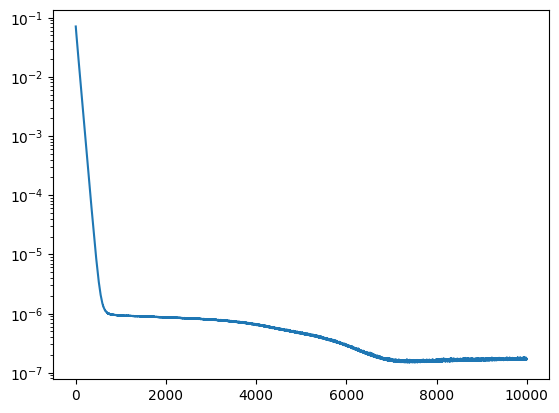

In [18]:
model = GeneralNet(ks=[3, 32, 32, 1])
netp = NetWithPartials.create_from_model(model=model, nz=0, nx=3)
params = model.params
lr_init = 1e-2
# optim = torch.optim.Adam(model.parameters(), lr=lr_init)
optim = HandNGD(model, lr=lr_init, config=config)
sample_on_surface = True
sampling_method = "binary_search" # one of ["random", "binary_search"]
surf_pts_nof_points = 100000 ## approx number to initialize the search with
bounds = torch.tensor([[0,1], [0,1], [0,1]])

loss_over_iters = {}

for i in (pbar:=trange(10000)):
    optim.zero_grad()

    ## 1) Interface at boundaries
    loss_interface  = 0.5*model.f(params, pts_boundary).square().mean()
    loss_interface += loss_weights["interface_corners"] * 0.5*model.f(params, pts_corners).square().mean()

    ## 2) Eikonal at boundaries (or everywhere?)
    loss_eikonal  = 0.5*(model.vf_x(params, pts_eikonal).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

    if sample_on_surface:
        if sampling_method=="random":
            pts_space = torch.rand([10000, 3])
            vals_sq = model(pts_space).square().squeeze()
            pts = pts_space[vals_sq<1e-4]
            if len(pts):
                pts_space = pts
        elif sampling_method=="binary_search":
            grid_find_surface, grid_dist_find_surface, init_grid_resolution = precompute_sample_grid(
                surf_pts_nof_points, bounds, equidistant=True)

            success, (p_surface, y_sel) = find_boundary_points_numerically_with_binsearch(
                netp=netp, 
                z=torch.zeros([1,0]), ## or correct shape with degenerate shape 
                n_steps=20,
                x_grid=grid_find_surface, 
                x_grid_dist=grid_dist_find_surface, 
                level_set=0.0,
                resolution=init_grid_resolution
                )
            if success:
                mask = torch.abs(y_sel)<1e-3 ## there is some error in the sampler which produces outliers. This is a simple hotfix until we fix it
                pts_space = p_surface.data[mask]
                pts_space = torch.cat((pts_space_fixed, pts_space))
            else:
                pts_space = pts_space_fixed
                # print("Warning: failed. Surface points will be outdated.")
                pass ## TODO: probably need to have a fallback to handle this case, and nans more generally
        else:
            assert False, "Point sampling method unknown"
        # pts_space = torch.cat((pts_space_fixed, pts_space))
        config["pts_space"] = pts_space
        optim.config = config
    loss_laplacian = 0.5*model.v_f_laplace(params, pts_space).squeeze(1).square().mean()
       
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["laplacian"] * loss_laplacian

    loss.backward()
    optim.step()
    with torch.no_grad():
        loss_metric = loss_interface + loss_laplacian

        pbar.set_description(f"interface: {loss_interface.item():.2e} "
                            f"eikonal: {loss_eikonal.item():.2e} "
                            f"laplacian: {loss_laplacian.item():.2e} "
                            f"{len(pts_space)}"
                            )
        loss_over_iters[i] = loss_metric.item()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

### Visualize the result

In [19]:
from util.visualization.utils_mesh import get_mesh

verts, faces = get_mesh(model, N=128, device=device, bbox_min=bounds[:,0]-.01, bbox_max=bounds[:,1]+.01, chunks=2)

In [20]:
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.line(pts_corners.cpu(), color=0x00ff00, shader='mesh', radial_segments=4, opacity=.5)
fig += k3d.points(pts_space.cpu(), point_size=0.01)
fig.display()

Output()

In [11]:
import torch

# Save the loss dictionary
loss_file = "loss_over_iters_adam_moving.pth"
torch.save(loss_over_iters, loss_file)
print(f"Loss saved to {loss_file}")

# Save the model parameters
model_file = "trained_model_adam_moving.pth"
torch.save(model.state_dict(), model_file)
print(f"Model saved to {model_file}")

Loss saved to loss_over_iters_adam_moving.pth
Model saved to trained_model_adam_moving.pth


In [12]:
# Save the K3D plot as an HTML file
fig_output_file = "k3d_plot_adam_moving.html"
with open(fig_output_file, 'w') as f:
    f.write(fig.get_snapshot())
print(f"Plot saved to {fig_output_file}")


Plot saved to k3d_plot_adam_moving.html


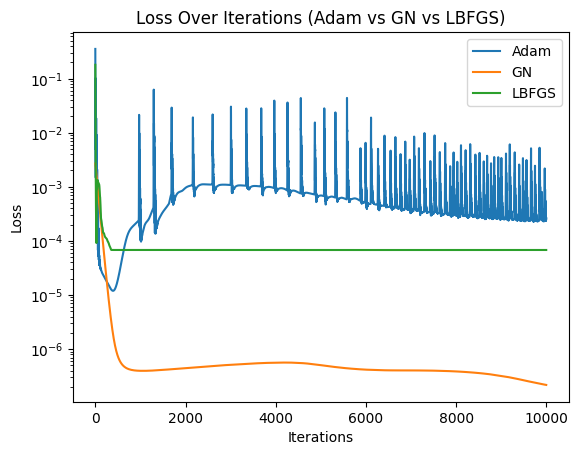

In [28]:
import torch
import matplotlib.pyplot as plt

# Load the loss data
loss_over_iters_adam = torch.load("loss_over_iters_adam.pth")
loss_over_iters_gn = torch.load("loss_over_iters_gn.pth")
loss_over_iters_lbfgs = torch.load("loss_over_iters_lbfgs.pth")  # Add LBFGS data

# Extract keys (iterations) and values (losses)
adam_iterations = list(loss_over_iters_adam.keys())
adam_values = list(loss_over_iters_adam.values())

gn_iterations = list(loss_over_iters_gn.keys())
gn_values = list(loss_over_iters_gn.values())

lbfgs_iterations = list(loss_over_iters_lbfgs.keys())
lbfgs_values = list(loss_over_iters_lbfgs.values())

# Plot all three losses
plt.plot(adam_iterations, adam_values, label="Adam")
plt.plot(gn_iterations, gn_values, label="GN")
plt.plot(lbfgs_iterations, lbfgs_values, label="LBFGS")  # Add LBFGS to the plot

plt.semilogy()  # Use logarithmic scale for the y-axis
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Over Iterations (Adam vs GN vs LBFGS)")
plt.legend()
plt.savefig("loss_comparison.png")
plt.show()




  0%|          | 0/10000 [00:00<?, ?it/s]

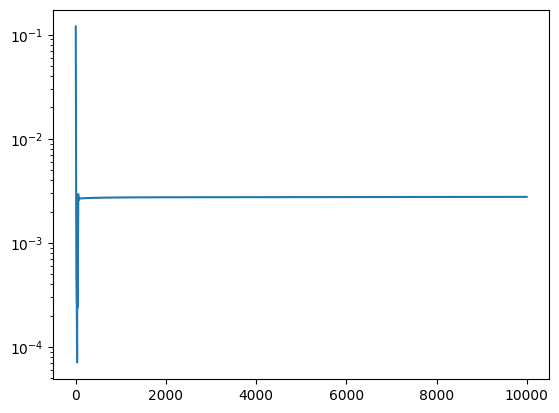

In [15]:
model = GeneralNet(ks=[3, 32, 32, 1])
params = model.params
lr_init = 1e-2
optim = torch.optim.LBFGS(model.parameters(), lr=lr_init, max_iter=20, tolerance_grad=1e-7, tolerance_change=1e-9)

loss_over_iters = {}

for i in (pbar := trange(10000)):
    def closure():
        optim.zero_grad()  # Reset gradients
        params_clone = {key: tensor.clone().detach() for key, tensor in params.items()}

        ## 1) Interface at boundaries
        loss_interface  = 0.5 * model.f(params, pts_boundary).square().mean()
        loss_interface += loss_weights["interface_corners"] * 0.5 * model.f(params, pts_corners).square().mean()

        ## 2) Eikonal at boundaries (or everywhere?)
        loss_eikonal  = 0.5 * (model.vf_x(params, pts_boundary).squeeze(1).square().sum(1).sqrt() - 1).square().mean()
        # loss_eikonal += 10 * (vf_x(params, pts_corners).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

        if sample_on_surface:
            pts_space = torch.rand([10000, 3])
            vals_sq = model(pts_space).square().squeeze()
            pts = pts_space[vals_sq<1e-4]
            if len(pts):
                pts_space = pts
            config["pts_space"] = pts_space
            optim.config = config
        loss_laplacian = 0.5*model.v_f_laplace(params, pts_space).squeeze(1).square().mean()

        # Total loss
        loss = (
            loss_weights["interface"] * loss_interface +
            loss_weights["eikonal"] * loss_eikonal +
            loss_weights["laplacian"] * loss_laplacian
        )

        loss.backward()  # Compute gradients
        return loss

    # Step the optimizer using the closure
    loss = optim.step(closure)

    with torch.no_grad():
        # Recompute the losses to update the progress bar
        loss_interface = 0.5 * model.f(params, pts_boundary).square().mean()
        loss_interface += loss_weights["interface_corners"] * 0.5 * model.f(params, pts_corners).square().mean()
        loss_eikonal = 0.5 * (model.vf_x(params, pts_boundary).squeeze(1).square().sum(1).sqrt() - 1).square().mean()
        loss_laplacian = 0.5 * model.v_f_laplace(params, pts_space).squeeze(1).square().mean()
        loss_metric = loss_interface + loss_laplacian

        pbar.set_description(
            f"interface: {loss_interface.item():.2e} "
            f"eikonal: {loss_eikonal.item():.2e} "
            f"laplacian: {loss_laplacian.item():.2e} "
        )
        loss_over_iters[i] = loss_metric.item()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()
